# Clustering Algorithms — Comparative Analysis

**Objective**: Compare the performance of four clustering algorithms across three different dataset shapes.

| Algorithm | Key Idea | Assumes Shape |
|---|---|---|
| **K-Means** | Minimises within-cluster variance | Convex / spherical |
| **Agglomerative** | Bottom-up hierarchical merging | Flexible (depends on linkage) |
| **DBSCAN** | Density-based — groups dense regions | Arbitrary shape |
| **Gaussian Mixture** | Probabilistic — fits Gaussian distributions | Elliptical |

-

| Metric | Interpretation | Better when |
|---|---|---|
| **Silhouette Score** | Cohesion vs separation, range [−1, 1] | Closer to 1 |
| **Davies-Bouldin Index** | Avg similarity of each cluster to its most similar cluster | Lower |
| **Calinski-Harabasz Index** | Ratio of between- to within-cluster dispersion | Higher |
| **Adjusted Rand Index** | Agreement with ground-truth labels | Closer to 1 |
| **Runtime** | Wall-clock time to fit | Lower |

-

| Section | Description |
|---|---|
| 1 | Datasets |
| 2 | Algorithm Implementations |
| 3 | Visual Comparison per Dataset |
| 4 | Metric Comparison |
| 5 | Runtime Comparison |
| 6 | Summary |

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score
)

np.random.seed(42)
print('All imports successful.')

All imports successful.


## 1. Datasets

Three datasets are used to stress-test each algorithm's assumptions:

| Dataset | Shape | Why useful |
|---|---|---|
| **Blobs** | Well-separated convex clusters | Baseline — all algorithms should do well |
| **Moons + Circles** | Non-convex, interleaved | Exposes failure of distance-based methods |
| **Iris** | Real-world, 4D, overlapping | Tests generalisation to real data |

Blobs (4 clusters)              shape=(400, 2)  k=4
Moons + Circles (4)             shape=(400, 2)  k=4
Iris (3 clusters)               shape=(150, 4)  k=3


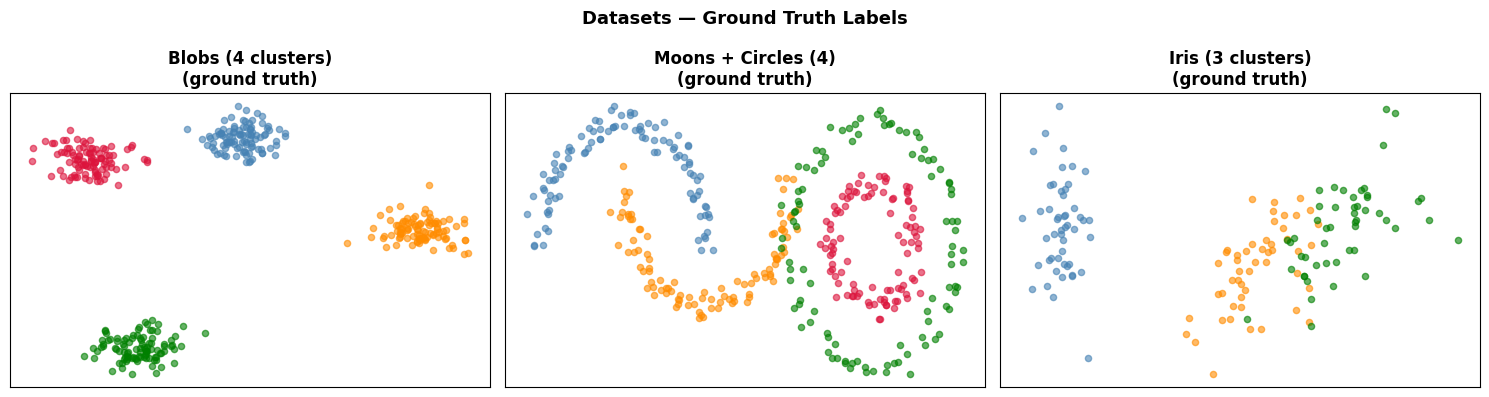

In [11]:
# --- Dataset 1: Blobs ---
X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

# --- Dataset 2: Moons + Circles (combined) ---
X_moons, y_moons = make_moons(n_samples=200, noise=0.07, random_state=42)
X_circ,  y_circ  = make_circles(n_samples=200, noise=0.07, factor=0.5, random_state=42)
X_circ[:, 0] += 3.0   # shift circles to the right
y_circ += 2            # offset class labels
X_nonconvex = np.vstack([X_moons, X_circ])
y_nonconvex = np.hstack([y_moons, y_circ])
X_nonconvex = StandardScaler().fit_transform(X_nonconvex)

# --- Dataset 3: Iris ---
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

DATASETS = {
    'Blobs (4 clusters)':      (X_blobs,     y_blobs,     4),
    'Moons + Circles (4)':     (X_nonconvex, y_nonconvex, 4),
    'Iris (3 clusters)':       (X_iris,      y_iris,      3),
}

for name, (X, y, k) in DATASETS.items():
    print(f'{name:30s}  shape={X.shape}  k={k}')

# Preview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = ['steelblue', 'darkorange', 'green', 'crimson']

for ax, (name, (X, y, k)) in zip(axes, DATASETS.items()):
    Xp = PCA(n_components=2).fit_transform(X) if X.shape[1] > 2 else X
    for cls in np.unique(y):
        ax.scatter(Xp[y == cls, 0], Xp[y == cls, 1],
                   color=palette[cls % len(palette)], alpha=0.6, s=20)
    ax.set_title(f'{name}\n(ground truth)', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Datasets — Ground Truth Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Algorithm Implementations

Each algorithm is wrapped in a helper that returns labels and runtime.

In [12]:
def run_kmeans(X, k):
    t0 = time.time()
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    return labels, time.time() - t0

def run_agglomerative(X, k):
    t0 = time.time()
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    return labels, time.time() - t0

def run_dbscan(X, eps=0.4, min_samples=5):
    t0 = time.time()
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    return labels, time.time() - t0

def run_gmm(X, k):
    t0 = time.time()
    labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X)
    return labels, time.time() - t0

# DBSCAN eps tuned per dataset shape
DBSCAN_PARAMS = {
    'Blobs (4 clusters)':  dict(eps=0.5,  min_samples=5),
    'Moons + Circles (4)': dict(eps=0.25, min_samples=5),
    'Iris (3 clusters)':   dict(eps=0.7,  min_samples=5),
}

ALGORITHMS = {
    'K-Means':       run_kmeans,
    'Agglomerative': run_agglomerative,
    'DBSCAN':        run_dbscan,
    'GMM':           run_gmm,
}

print('Algorithms ready.')

Algorithms ready.


## 3. Visual Comparison per Dataset

Each row is a dataset. Each column is an algorithm. Colour = predicted cluster label.

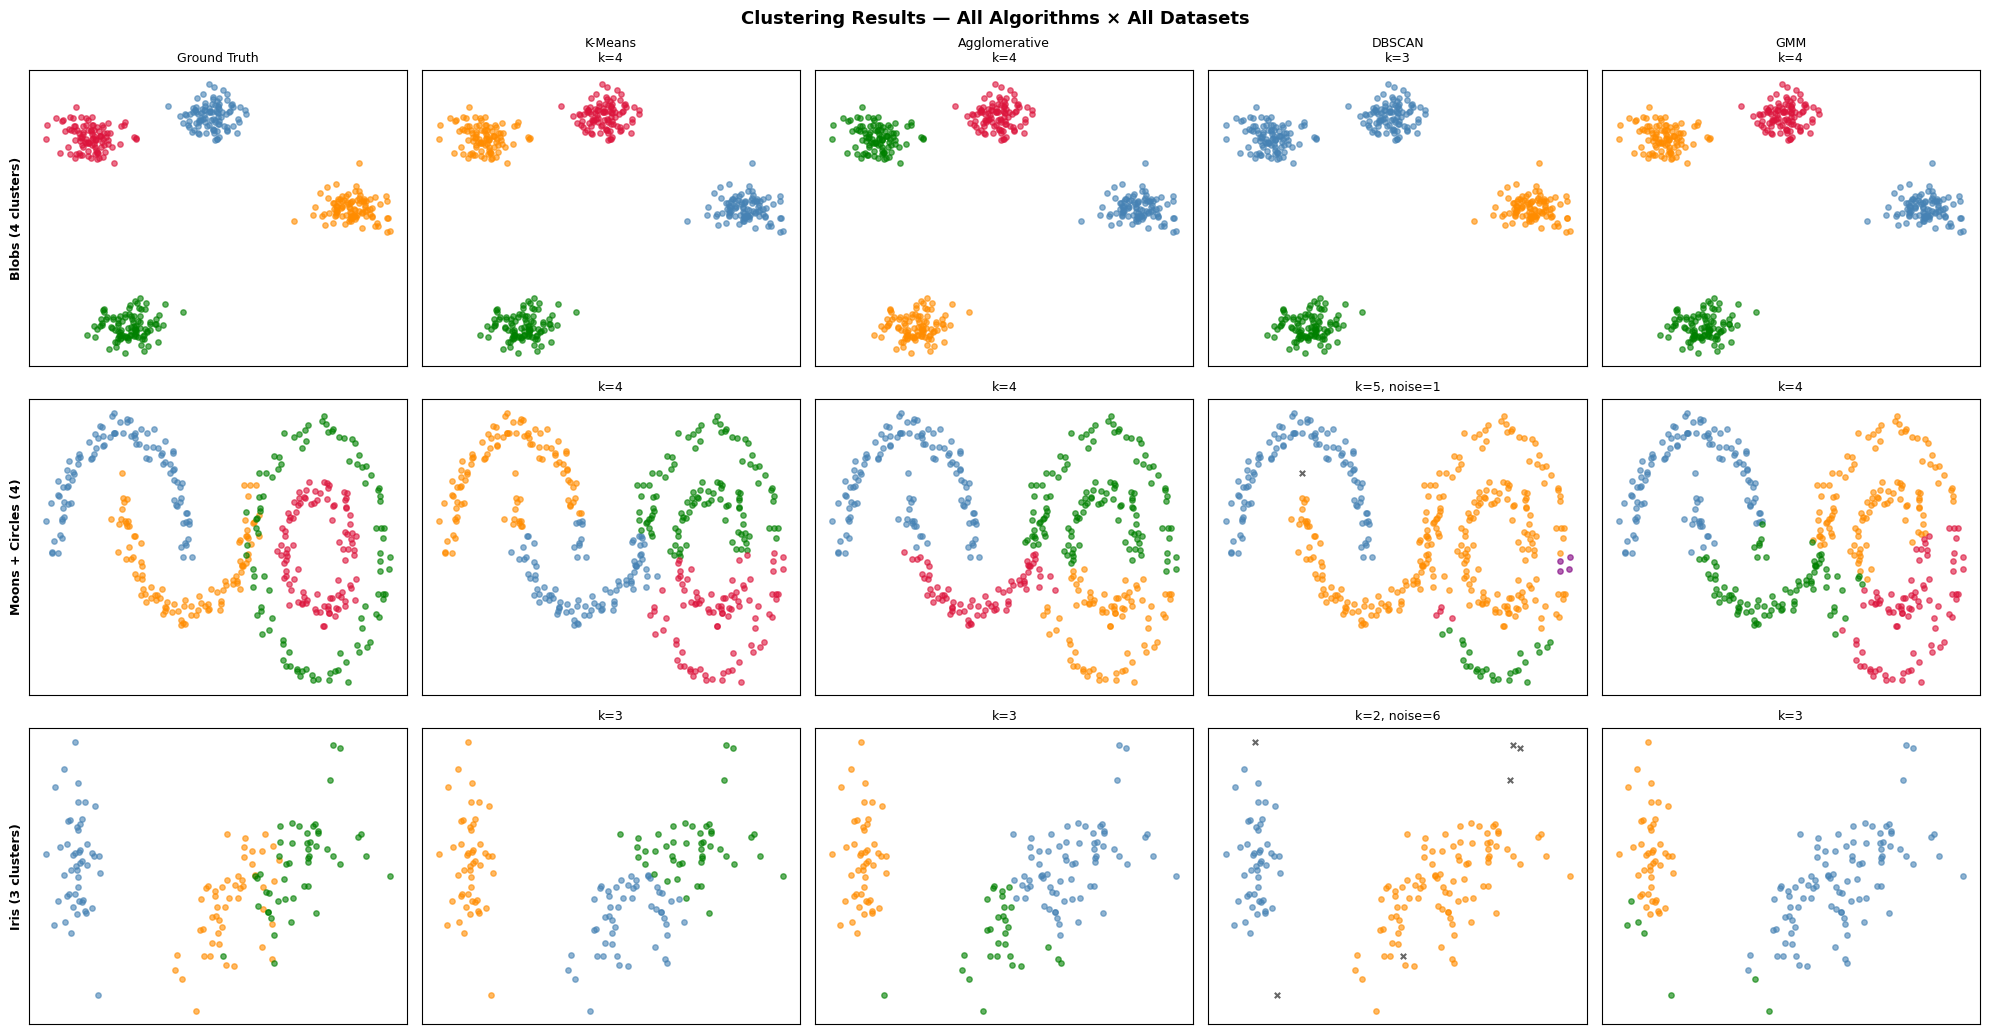

In [4]:
COLORS = ['steelblue', 'darkorange', 'green', 'crimson',
          'purple', 'brown', 'pink', 'gray']

n_datasets = len(DATASETS)
n_algos    = len(ALGORITHMS)

fig, axes = plt.subplots(n_datasets, n_algos + 1,
                         figsize=(4 * (n_algos + 1), 3.5 * n_datasets))

# Store all results for metric computation later
all_results = {}   # all_results[dataset_name][algo_name] = (labels, runtime)

for row, (ds_name, (X, y_true, k)) in enumerate(DATASETS.items()):
    Xp = PCA(n_components=2).fit_transform(X) if X.shape[1] > 2 else X
    all_results[ds_name] = {}

    # Ground truth column
    ax = axes[row, 0]
    for cls in np.unique(y_true):
        ax.scatter(Xp[y_true == cls, 0], Xp[y_true == cls, 1],
                   color=COLORS[cls % len(COLORS)], alpha=0.6, s=15)
    ax.set_title('Ground Truth' if row == 0 else '', fontsize=9)
    ax.set_ylabel(ds_name, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    for col, (algo_name, algo_fn) in enumerate(ALGORITHMS.items()):
        ax = axes[row, col + 1]

        if algo_name == 'DBSCAN':
            labels, rt = run_dbscan(X, **DBSCAN_PARAMS[ds_name])
        else:
            labels, rt = algo_fn(X, k)

        all_results[ds_name][algo_name] = (labels, rt)

        unique_labels = np.unique(labels)
        for lbl in unique_labels:
            mask = labels == lbl
            color = 'black' if lbl == -1 else COLORS[lbl % len(COLORS)]
            marker = 'x' if lbl == -1 else 'o'
            ax.scatter(Xp[mask, 0], Xp[mask, 1],
                       color=color, alpha=0.6, s=15, marker=marker)

        n_clusters = len(set(labels) - {-1})
        n_noise    = (labels == -1).sum()
        title = f'{algo_name}\nk={n_clusters}' if row == 0 else f'k={n_clusters}'
        if n_noise > 0:
            title += f', noise={n_noise}'
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Clustering Results — All Algorithms × All Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Metric Comparison

Quantitative scores for every algorithm–dataset combination.

In [5]:
def safe_score(fn, X, labels):
    """Return NaN if fewer than 2 clusters or all noise."""
    valid = labels[labels != -1]
    if len(np.unique(valid)) < 2:
        return np.nan
    X_valid = X[labels != -1]
    l_valid = labels[labels != -1]
    try:
        return fn(X_valid, l_valid)
    except Exception:
        return np.nan

records = []
for ds_name, (X, y_true, k) in DATASETS.items():
    for algo_name, (labels, rt) in all_results[ds_name].items():
        sil = safe_score(silhouette_score,       X, labels)
        dbi = safe_score(davies_bouldin_score,   X, labels)
        chi = safe_score(calinski_harabasz_score, X, labels)
        # ARI uses ground truth
        valid_mask = labels != -1
        ari = adjusted_rand_score(y_true[valid_mask], labels[valid_mask]) if valid_mask.sum() > 0 else np.nan
        n_clusters = len(set(labels) - {-1})
        records.append({
            'Dataset': ds_name, 'Algorithm': algo_name,
            'k found': n_clusters,
            'Silhouette ↑': round(sil, 4) if not np.isnan(sil) else np.nan,
            'Davies-Bouldin ↓': round(dbi, 4) if not np.isnan(dbi) else np.nan,
            'Calinski-Harabasz ↑': round(chi, 1) if not np.isnan(chi) else np.nan,
            'ARI ↑': round(ari, 4),
            'Runtime (ms)': round(rt * 1000, 2)
        })

metrics_df = pd.DataFrame(records)
metrics_df

,Dataset,Algorithm,k found,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI ↑,Runtime (ms)
0,Blobs (4 clusters),K-Means,4,0.8202,0.2502,5472.3,1.0000,104.52
1,Blobs (4 clusters),Agglomerative,4,0.8202,0.2502,5472.3,1.0000,78.83
2,Blobs (4 clusters),DBSCAN,3,0.7536,0.3592,1511.7,0.7127,6.01
3,Blobs (4 clusters),GMM,4,0.8202,0.2502,5472.3,1.0000,41.31
4,Moons + Circles (4),K-Means,4,0.4562,0.7327,479.5,0.4556,199.74
5,Moons + Circles (4),Agglomerative,4,0.4412,0.7077,441.1,0.4606,15.32
6,Moons + Circles (4),DBSCAN,5,-0.0100,0.9651,97.5,0.3643,6.84
7,Moons + Circles (4),GMM,4,0.4346,0.7444,435.1,0.4079,56.96
8,Iris (3 clusters),K-Means,3,0.4599,0.8336,241.9,0.6201,164.12
9,Iris (3 clusters),Agglomerative,3,0.4467,0.8035,222.7,0.6153,4.61


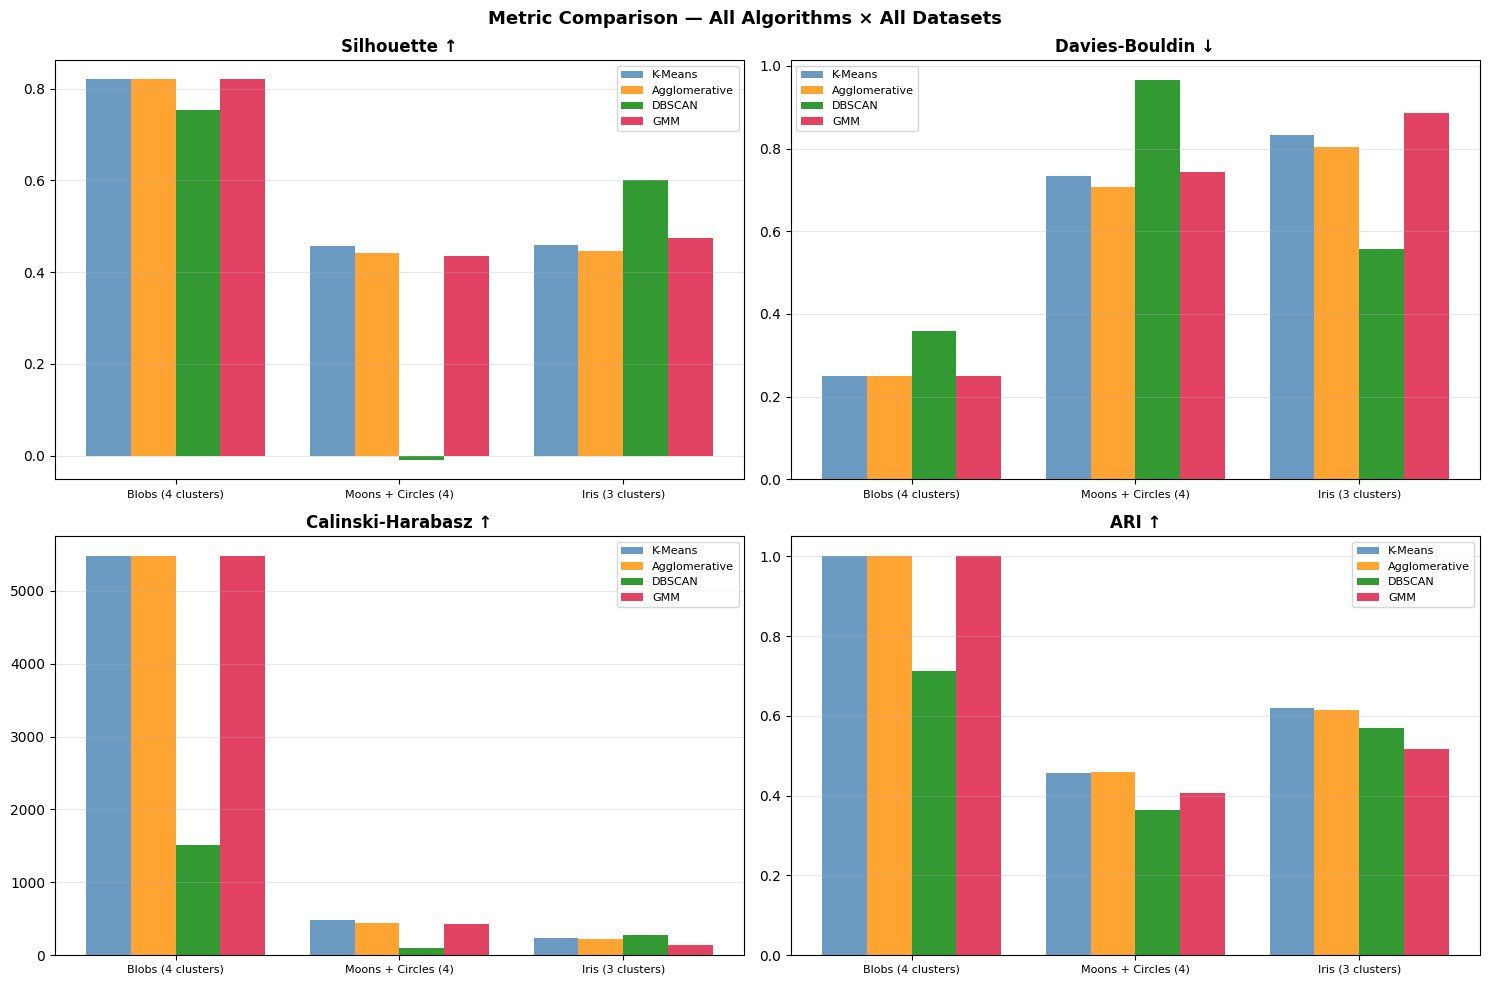

In [6]:
# Metric bar charts — one subplot per metric, grouped by dataset
metric_cols = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑', 'ARI ↑']
algo_names  = list(ALGORITHMS.keys())
ds_names    = list(DATASETS.keys())
algo_colors = ['steelblue', 'darkorange', 'green', 'crimson']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, metric in zip(axes.flat, metric_cols):
    x = np.arange(len(ds_names))
    width = 0.2
    for i, (algo, color) in enumerate(zip(algo_names, algo_colors)):
        vals = [
            metrics_df[(metrics_df['Dataset'] == ds) &
                        (metrics_df['Algorithm'] == algo)][metric].values[0]
            for ds in ds_names
        ]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, vals, width, label=algo, color=color, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(ds_names, fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Metric Comparison — All Algorithms × All Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Runtime Comparison

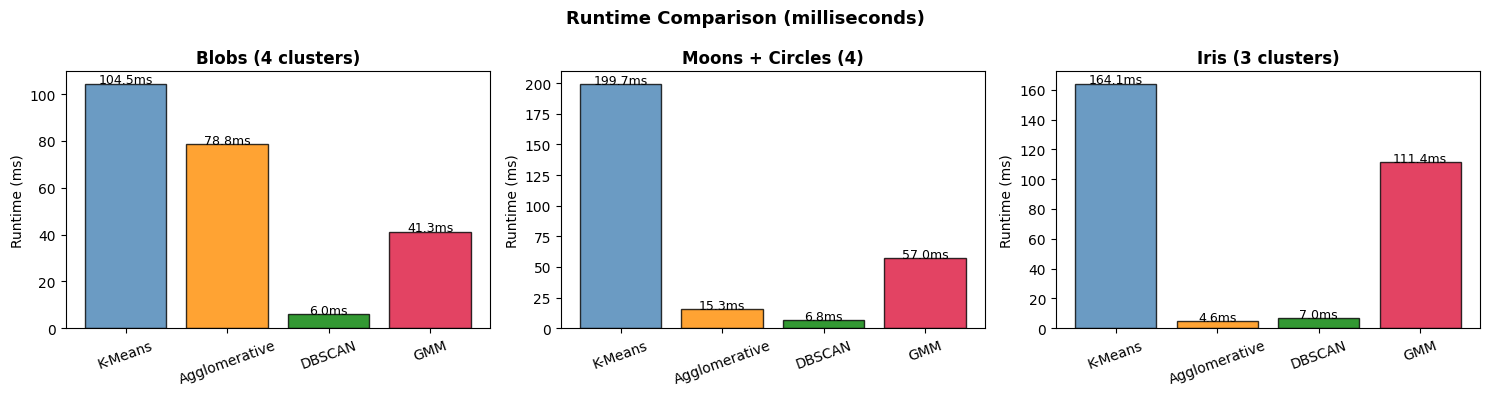

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ds_name in zip(axes, ds_names):
    rt_vals = [
        metrics_df[(metrics_df['Dataset'] == ds_name) &
                   (metrics_df['Algorithm'] == algo)]['Runtime (ms)'].values[0]
        for algo in algo_names
    ]
    bars = ax.bar(algo_names, rt_vals, color=algo_colors, alpha=0.8, edgecolor='black')
    for bar, v in zip(bars, rt_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                f'{v:.1f}ms', ha='center', fontsize=9)
    ax.set_title(ds_name, fontweight='bold')
    ax.set_ylabel('Runtime (ms)')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Runtime Comparison (milliseconds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

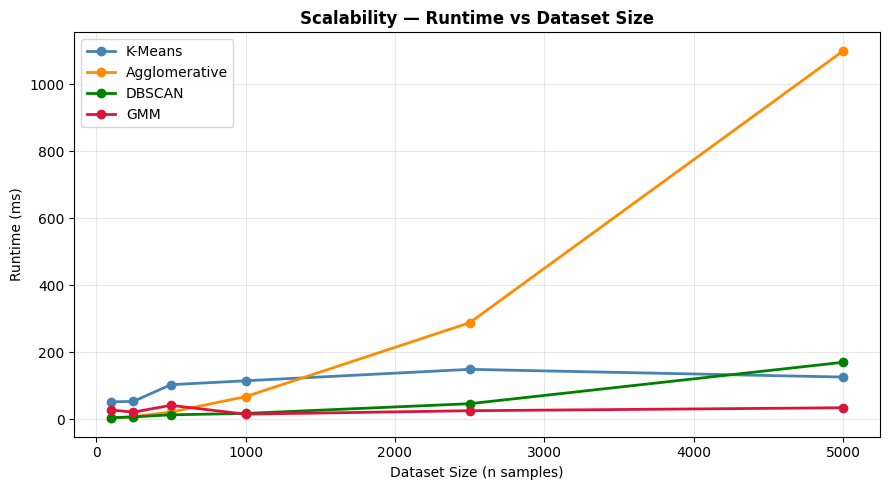

In [8]:
# Scalability — runtime vs dataset size (K-Means vs DBSCAN vs GMM vs Agglomerative)
sizes = [100, 250, 500, 1000, 2500, 5000]
scale_results = {algo: [] for algo in algo_names}

for n in sizes:
    Xs, _ = make_blobs(n_samples=n, centers=4, random_state=42)
    Xs = StandardScaler().fit_transform(Xs)
    scale_results['K-Means'].append(run_kmeans(Xs, 4)[1] * 1000)
    scale_results['Agglomerative'].append(run_agglomerative(Xs, 4)[1] * 1000)
    scale_results['DBSCAN'].append(run_dbscan(Xs, eps=0.5)[1] * 1000)
    scale_results['GMM'].append(run_gmm(Xs, 4)[1] * 1000)

fig, ax = plt.subplots(figsize=(9, 5))
for algo, color in zip(algo_names, algo_colors):
    ax.plot(sizes, scale_results[algo], 'o-', color=color, lw=2, markersize=6, label=algo)
ax.set_xlabel('Dataset Size (n samples)')
ax.set_ylabel('Runtime (ms)')
ax.set_title('Scalability — Runtime vs Dataset Size', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

In [9]:
# Best algorithm per dataset per metric
print('Best algorithm per metric per dataset:\n')
for ds in ds_names:
    sub = metrics_df[metrics_df['Dataset'] == ds].set_index('Algorithm')
    print(f'  {ds}')
    print(f'    Silhouette (↑)        : {sub["Silhouette ↑"].idxmax()}')
    print(f'    Davies-Bouldin (↓)    : {sub["Davies-Bouldin ↓"].idxmin()}')
    print(f'    Calinski-Harabasz (↑) : {sub["Calinski-Harabasz ↑"].idxmax()}')
    print(f'    ARI (↑)               : {sub["ARI ↑"].idxmax()}')
    print(f'    Fastest               : {sub["Runtime (ms)"].idxmin()}')
    print()

Best algorithm per metric per dataset:

  Blobs (4 clusters)
    Silhouette (↑)        : K-Means
    Davies-Bouldin (↓)    : K-Means
    Calinski-Harabasz (↑) : K-Means
    ARI (↑)               : K-Means
    Fastest               : DBSCAN

  Moons + Circles (4)
    Silhouette (↑)        : K-Means
    Davies-Bouldin (↓)    : Agglomerative
    Calinski-Harabasz (↑) : K-Means
    ARI (↑)               : Agglomerative
    Fastest               : DBSCAN

  Iris (3 clusters)
    Silhouette (↑)        : DBSCAN
    Davies-Bouldin (↓)    : DBSCAN
    Calinski-Harabasz (↑) : DBSCAN
    ARI (↑)               : K-Means
    Fastest               : Agglomerative



### Conclusions

| Algorithm | Strengths | Weaknesses | Best for |
|---|---|---|---|
| **K-Means** | Fast, scalable, simple | Assumes spherical clusters, needs k upfront | Large convex datasets |
| **Agglomerative** | No shape assumption (ward linkage), dendrogram available | O(n²) memory, slow on large data | Small/medium datasets, hierarchical structure |
| **DBSCAN** | Finds arbitrary shapes, detects noise/outliers, no k needed | Sensitive to `eps` and `min_samples`, struggles with varying density | Spatial data, noisy datasets |
| **GMM** | Soft assignments, handles elliptical clusters, probabilistic output | Assumes Gaussian, sensitive to initialisation | Overlapping clusters, when probabilities matter |

**Key takeaways from this experiment:**
- On **Blobs**: all algorithms score similarly — easy dataset
- On **Moons + Circles**: DBSCAN uniquely recovers the true structure; K-Means and GMM fail on non-convex shapes
- On **Iris**: K-Means and GMM match ground truth well; Agglomerative is competitive; DBSCAN is sensitive to `eps`
- **Runtime**: K-Means is fastest overall; Agglomerative is slowest at scale (O(n²) complexity)